# PCL Classifier — Training Pipeline

Binary classification: predict whether a news paragraph contains Patronizing and
Condescending Language (PCL) towards a vulnerable community.

**Evaluation metric:** F1 of the positive class only.

**Key techniques:**
- Dual backbone: `roberta-base` and `distilbert-base-uncased`, ensembled via weighted probability averaging
- Grouped Layer-wise Learning Rate Decay (Grouped LLRD)
- Weighted Random Sampler (WRS) to handle 9.5:1 class imbalance
- Cosine annealing scheduler with linear warmup
- Metadata (keyword + country) prepended to each paragraph
- Multi-seed training (3 seeds per model) to reduce variance
- Early stopping on validation F1, threshold tuning post-training
- Automatic fallback: solo RoBERTa vs. weighted ensemble, whichever generalises better

**Data split:**
- Official train (8,375) → stratified 90/10 → our **train** + **validation**
- Official dev (2,094) → our held-out **test** (labels available for local evaluation)
- Official test (3,832) → unlabelled; generate `test.txt` for leaderboard

---

**Training results — RoBERTa (GPU: Tesla T4, seeds: 42 / 7 / 123, dropout=0.1):**

| Model | seed=42 val F1* | seed=7 val F1* | seed=123 val F1* | Best seed |
|---|---|---|---|---|
| `roberta-base` | 0.6047 | 0.6082 | **0.6289** | seed=123 |

**Training results — DistilBERT sweep (dropout=0.1, bs=8, ga=2):**

| Model | seed=42 val F1* | seed=7 val F1* | seed=123 val F1* | Best seed |
|---|---|---|---|---|
| `distilbert-base-uncased` | 0.5596 | **0.5965** | 0.5965 | seed=7 |

**Final evaluation (held-out test set, 2,094 rows):**

| System | Val F1* | Test F1 | Threshold |
|---|---|---|---|
| Solo RoBERTa (seed=123) | 0.6289 | **0.5344** | 0.60 |
| DistilBERT (seed=7) | 0.5965 | TBD | TBD |
| Ensemble (RoBERTa + DistilBERT) | TBD | TBD | TBD |

**Best checkpoints saved to:** `BestModel/roberta-base/` and `BestModel/distilbert/`.

In [1]:
# !pip install transformers torch scikit-learn pandas numpy tqdm seaborn tiktoken

In [2]:
import os, sys, html, random, warnings, platform
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")

sys.path.append(os.path.dirname(os.path.abspath("__file__")))
from dont_patronize_me import DontPatronizeMe


def set_seed(seed=42):
    """Set random seeds for reproducibility across all backends."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


def get_device():
    """Select best available compute device: CUDA > Apple MPS > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")


set_seed(42)
DEVICE = get_device()

print(f"Using device: {DEVICE}")
print(f"Host: {platform.node()}")
print(f"Python: {sys.executable}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
print(f"PyTorch: {torch.__version__}  CUDA build: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}  GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/vol/bitbucket/da1823/pcl-classifier/.venv-notebook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Host: gpuvm13.doc.ic.ac.uk
Python: /vol/bitbucket/da1823/pcl-classifier/.venv-notebook/bin/python
CUDA_VISIBLE_DEVICES: 0
PyTorch: 2.10.0+cu128  CUDA build: 12.8
CUDA available: True  GPU count: 1
GPU: Tesla T4


## 1. Data Loading and Preprocessing

We load all annotated paragraphs via the helper class, then filter to the
official train/dev splits using the provided par_id CSV files.

The official dev set (2,094 rows) is treated as our **held-out test** since
the official test set has no labels. We further split the official train into
our own 90/10 train/validation split (stratified by label).

In [3]:
DATA_DIR = "../data"

# Load all 10,469 labelled paragraphs
dpm = DontPatronizeMe(DATA_DIR, os.path.join(DATA_DIR, "task4_test.tsv"))
dpm.load_task1()
full_df = dpm.train_task1_df.copy()
full_df["par_id"] = full_df["par_id"].astype(str)
full_df["orig_label"] = full_df["orig_label"].astype(int)

# Load official train/dev par_id lists
train_ids = pd.read_csv(os.path.join(DATA_DIR, "train_semeval_parids-labels.csv"))
dev_ids   = pd.read_csv(os.path.join(DATA_DIR, "dev_semeval_parids-labels.csv"))
train_ids["par_id"] = train_ids["par_id"].astype(str)
dev_ids["par_id"]   = dev_ids["par_id"].astype(str)

# Filter into official splits
train_pool = full_df[full_df["par_id"].isin(train_ids["par_id"])].reset_index(drop=True)
test_df    = full_df[full_df["par_id"].isin(dev_ids["par_id"])].reset_index(drop=True)

# Stratified 90/10 split of the train pool → our train + validation
train_df, val_df = train_test_split(
    train_pool,
    test_size=0.10,
    stratify=train_pool["label"],
    random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)} rows  |  PCL: {train_df['label'].sum()} ({train_df['label'].mean():.1%})")
print(f"Val:   {len(val_df)} rows   |  PCL: {val_df['label'].sum()} ({val_df['label'].mean():.1%})")
print(f"Test:  {len(test_df)} rows  |  PCL: {test_df['label'].sum()} ({test_df['label'].mean():.1%})")

Train: 7537 rows  |  PCL: 715 (9.5%)
Val:   838 rows   |  PCL: 79 (9.4%)
Test:  2094 rows  |  PCL: 199 (9.5%)


In [4]:
def build_input_text(row):
    """Prepend keyword and country metadata using <e>...</e> entity-boundary tokens."""
    text = html.unescape(row["text"])
    return f"<e>{row['keyword']}</e> <e>{row['country']}</e> {text}"


for df in [train_df, val_df, test_df]:
    df["input_text"] = df.apply(build_input_text, axis=1)

# Load unlabelled test set for leaderboard submission
dpm.load_test()
submit_df = dpm.test_set_df.copy()
submit_df["input_text"] = submit_df.apply(build_input_text, axis=1)

print("Sample input:")
print(train_df["input_text"].iloc[0])

Sample input:
<e>refugee</e> <e>sg</e> A woman holding an umbrella walks in a flooded field during heavy rainfall at a makeshift camp for refugees and migrants at the Greek-Macedonian border near the village of Idomeni , Greece , May 21 , 2016 . REUTERS/Kostas Tsironis


## 2. Dataset and DataLoader

A minimal PyTorch Dataset tokenizes text on the fly.
For training we attach a **Weighted Random Sampler (WRS)** to the DataLoader.

**WRS formula:**  
Each sample weight = `1 / √(class_ratio)` where `class_ratio` is the fraction
of that class in the training set. The square-root dampens the correction,
making it softer than full inverse-frequency weighting.

In [5]:
class PCLDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = texts
        self.labels = labels  # None for unlabelled inference

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {"text": self.texts[idx]}
        if self.labels is not None:
            item["label"] = self.labels[idx]
        return item

In [6]:
MAX_LENGTH = 250  # covers 99th percentile of token lengths

# ── Weighted Random Sampler with sqrt-scaling + confidence weighting ──────────
labels_array   = train_df["label"].values
num_positive   = labels_array.sum()
num_negative   = len(labels_array) - num_positive
ratio_positive = num_positive / len(labels_array)
ratio_negative = num_negative / len(labels_array)

weight_positive = 1.0 / np.sqrt(ratio_positive)
weight_negative = 1.0 / np.sqrt(ratio_negative)
base_sample_weights = np.where(labels_array == 1, weight_positive, weight_negative)

# Ambiguous positives (orig_label == 2) receive half the sampling weight
CONFIDENCE_MULTIPLIER = {0: 1.0, 1: 1.0, 2: 0.5, 3: 1.0, 4: 1.0}
orig_labels_train = train_df["orig_label"].astype(int).values
confidence = np.array([CONFIDENCE_MULTIPLIER[label] for label in orig_labels_train])
sample_weights = base_sample_weights * confidence

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(train_df),
    replacement=True,
)
print(f"WRS weights — positive: {weight_positive:.3f}, negative: {weight_negative:.3f}")
print(f"Confidence-damped ambiguous positives: {(orig_labels_train == 2).sum()} samples at 0.5x")

# ── Datasets (tokenization happens per-model in the training cell) ──────────
train_dataset = PCLDataset(train_df["input_text"].tolist(), train_df["label"].tolist())
val_dataset   = PCLDataset(val_df["input_text"].tolist(),   val_df["label"].tolist())
test_dataset  = PCLDataset(test_df["input_text"].tolist(),  test_df["label"].tolist())

WRS weights — positive: 3.247, negative: 1.051
Confidence-damped ambiguous positives: 112 samples at 0.5x


## 3. Model and Optimizer

We use **Grouped Layer-wise Learning Rate Decay (Grouped LLRD)**.

The transformer layers are split into 3 groups from bottom to top, with
learning rates: `η/λ`, `η`, `η·λ` respectively.  
Bottom layers encode general syntactic features that should change
slowly; top layers encode task-specific features and can adapt faster.

**Chosen values:** η = 1e-5, λ = 1.6

In [7]:
def get_grouped_llrd_params(model, base_lr, lambda_val, weight_decay, n_groups=3):
    """
    Returns optimizer parameter groups with Grouped LLRD.

    Encoder layers are divided into n_groups from bottom (lowest LR) to top
    (highest LR). Embeddings join the bottom group; pooler and classifier join
    the top group.

    LR schedule: group g gets base_lr * lambda_val^(g - 1) for g in {0,1,2},
    which gives [base_lr/λ, base_lr, base_lr·λ] for groups [0, 1, 2].
    """
    if hasattr(model, "distilbert"):
        encoder_layers = model.distilbert.transformer.layer
        embeddings     = model.distilbert.embeddings
        backbone       = "distilbert"
    elif hasattr(model, "roberta"):
        encoder_layers = model.roberta.encoder.layer
        embeddings     = model.roberta.embeddings
        backbone       = "roberta"
    elif hasattr(model, "bert"):
        encoder_layers = model.bert.encoder.layer
        embeddings     = model.bert.embeddings
        backbone       = "bert"
    else:
        return [{"params": model.parameters(), "lr": base_lr}]

    n_layers   = len(encoder_layers)
    group_size = n_layers // n_groups

    # Layer index → learning rate
    def layer_lr(idx):
        group_idx = min(idx // group_size, n_groups - 1)
        return base_lr * (lambda_val ** (group_idx - 1))

    param_groups = []
    seen = set()

    def add_group(params_iter, lr):
        params = [p for p in params_iter if id(p) not in seen and p.requires_grad]
        for p in params:
            seen.add(id(p))
        if params:
            param_groups.append({"params": params, "lr": lr, "weight_decay": weight_decay})

    # Embeddings → bottom LR
    add_group(embeddings.parameters(), base_lr / lambda_val)

    # Encoder layers
    for i, layer in enumerate(encoder_layers):
        add_group(layer.parameters(), layer_lr(i))

    # Pooler / pre_classifier / classifier → top LR (most task-specific)
    top_lr = base_lr * lambda_val
    for attr in ("pooler", "pre_classifier", "classifier"):
        if hasattr(model, attr):
            m = getattr(model, attr)
            if m is not None:
                add_group(m.parameters(), top_lr)

    total_params = sum(p.numel() for g in param_groups for p in g["params"])
    print(f"Grouped LLRD: {len(param_groups)} param groups | {total_params:,} trainable params")
    for i, g in enumerate(param_groups):
        n = sum(p.numel() for p in g["params"])
        print(f"  Group {i}: lr={g['lr']:.2e}  params={n:,}")

    return param_groups

## 4. Train Two Models (RoBERTa + DistilBERT) — Multi-Seed

Set `TRAIN_MODE = True` to retrain from scratch with 3 seeds per model.  
Set `TRAIN_MODE = False` (default) to load existing best checkpoints from `BestModel/`.

- **`roberta-base`**: `roberta-base`, LR=1e-5, dropout=0.1, weight_decay=0.01, label_smoothing=0.0
- **`distilbert`**: `distilbert-base-uncased`, LR=2e-5, dropout=0.3, weight_decay=0.01, label_smoothing=0.0

The best checkpoints are later combined via **weighted probability averaging**
with a 2-D grid search over the ensemble weight `w` and classification threshold `t`.

In [8]:
def evaluate(model, loader, threshold=0.5):
    """Return probabilities, labels, and F1 against a given threshold."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels").numpy()
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels)
    preds = (np.array(all_probs) >= threshold).astype(int)
    f1    = f1_score(all_labels, preds, pos_label=1, zero_division=0)
    return np.array(all_probs), np.array(all_labels), f1


def eval_monitor(model, loader, thresholds=np.arange(0.1, 0.91, 0.01)):
    """Return F1@0.5 plus best-threshold F1 for robust training monitoring."""
    probs, labels, f1_at_05 = evaluate(model, loader, threshold=0.5)
    best_thr, best_f1 = 0.5, f1_at_05
    for thr in thresholds:
        f1_thr = f1_score(labels, (probs >= thr).astype(int), pos_label=1, zero_division=0)
        if f1_thr > best_f1:
            best_f1, best_thr = f1_thr, float(thr)
    return f1_at_05, best_f1, best_thr

In [9]:
import gc

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  Set TRAIN_MODE = True  to retrain from scratch (multi-seed).           ║
# ║  Set TRAIN_MODE = False to load existing best checkpoints (default).    ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
TRAIN_MODE = False

ENSEMBLE_CONFIGS = [
    {
        "tag": "roberta-base",
        "MODEL_NAME": "roberta-base",
        "BASE_LR": 1e-5, "DROPOUT": 0.1, "WEIGHT_DECAY": 0.01,
        "LABEL_SMOOTH": 0.0, "BATCH_SIZE": 8, "GRAD_ACCUM": 2,
    },
    {
        "tag": "distilbert",
        "MODEL_NAME": "distilbert-base-uncased",
        "BASE_LR": 2e-5, "DROPOUT": 0.3, "WEIGHT_DECAY": 0.01,
        "LABEL_SMOOTH": 0.0, "BATCH_SIZE": 8, "GRAD_ACCUM": 2,
    },
]

# Paths to pre-trained best checkpoints (used when TRAIN_MODE = False)
BEST_CHECKPOINT_DIR = {
    "roberta-base": "../BestModel/roberta-base",
    "distilbert":   "../BestModel/distilbert",
}

SEEDS        = [42, 7, 123]
N_EPOCHS     = 8
LAMBDA       = 1.6
N_GROUPS     = 3
WARMUP_RATIO = 0.10
PATIENCE     = 15
EVAL_STEPS   = 50

SAVE_ROOT     = "../SavedModels"
train_results = []
best_seed     = {}

if not TRAIN_MODE:
    # ── Load existing best checkpoints ───────────────────────────────────
    for tag, checkpoint_dir in BEST_CHECKPOINT_DIR.items():
        assert os.path.isdir(checkpoint_dir), f"Checkpoint not found: {checkpoint_dir}"
        best_seed[tag] = {"seed": None, "f1": None, "dir": checkpoint_dir}
        print(f"  Loaded {tag} from {checkpoint_dir}")
    print("\nTRAIN_MODE=False: skipping training, using existing checkpoints.\n")

# When TRAIN_MODE is False the loop body is skipped entirely
for cfg in (ENSEMBLE_CONFIGS if TRAIN_MODE else []):
    tag = cfg["tag"]
    is_distilbert = "distilbert" in cfg["MODEL_NAME"]

    for seed in SEEDS:
        set_seed(seed)
        run_name = f"{tag}/seed{seed}"
        print(f"\n{'='*65}")
        print(f"  {run_name}  ({cfg['MODEL_NAME']}  seed={seed})")
        print(f"{'='*65}")

        # ── Tokenizer ────────────────────────────────────────────────────
        tokenizer = AutoTokenizer.from_pretrained(cfg["MODEL_NAME"])
        tokenizer.add_special_tokens({"additional_special_tokens": ["<e>", "</e>"]})

        def collate_fn(batch, tok=tokenizer):
            texts  = [b["text"] for b in batch]
            labels = [b["label"] for b in batch] if "label" in batch[0] else None
            encoded = tok(texts, padding=True, truncation=True,
                          max_length=MAX_LENGTH, return_tensors="pt")
            if labels is not None:
                encoded["labels"] = torch.tensor(labels, dtype=torch.long)
            return encoded

        train_loader = DataLoader(train_dataset, batch_size=cfg["BATCH_SIZE"],
                                  sampler=sampler, collate_fn=collate_fn)
        val_loader   = DataLoader(val_dataset, batch_size=cfg["BATCH_SIZE"] * 2,
                                  shuffle=False, collate_fn=collate_fn)

        # ── Model ────────────────────────────────────────────────────────
        # DistilBERT uses different dropout config keys to RoBERTa
        if is_distilbert:
            dropout_kwargs = {
                "dropout": cfg["DROPOUT"],
                "attention_dropout": cfg["DROPOUT"],
                "seq_classif_dropout": cfg["DROPOUT"],
            }
        else:
            dropout_kwargs = {
                "hidden_dropout_prob": cfg["DROPOUT"],
                "attention_probs_dropout_prob": cfg["DROPOUT"],
            }
        model = AutoModelForSequenceClassification.from_pretrained(
            cfg["MODEL_NAME"], num_labels=2,
            ignore_mismatched_sizes=True,
            **dropout_kwargs,
        )
        model.resize_token_embeddings(len(tokenizer))
        model.float().to(DEVICE)

        # ── Optimizer / Scheduler / Loss ─────────────────────────────────
        param_groups = get_grouped_llrd_params(
            model, cfg["BASE_LR"], LAMBDA, cfg["WEIGHT_DECAY"], N_GROUPS
        )
        optimizer    = AdamW(param_groups, eps=1e-6)
        total_steps  = (len(train_loader) // cfg["GRAD_ACCUM"]) * N_EPOCHS
        warmup_steps = int(WARMUP_RATIO * total_steps)
        scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        loss_fn      = nn.CrossEntropyLoss(label_smoothing=cfg["LABEL_SMOOTH"])

        print(f"  Steps: {total_steps}  |  Warmup: {warmup_steps}")

        best_val_f1      = -1.0
        best_state_dict  = None
        patience_counter = 0
        global_step      = 0

        for epoch in range(1, N_EPOCHS + 1):
            model.train()
            optimizer.zero_grad()
            running_loss  = 0.0
            early_stopped = False

            progress = tqdm(train_loader, desc=f"{run_name} Ep {epoch}/{N_EPOCHS}")
            for step, batch in enumerate(progress):
                labels = batch.pop("labels").to(DEVICE)
                batch  = {k: v.to(DEVICE) for k, v in batch.items()}
                loss = loss_fn(model(**batch).logits, labels) / cfg["GRAD_ACCUM"]
                loss.backward()
                running_loss += loss.item() * cfg["GRAD_ACCUM"]

                if (step + 1) % cfg["GRAD_ACCUM"] == 0 or (step + 1) == len(train_loader):
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()
                    global_step += 1

                    # Mid-epoch validation
                    if global_step % EVAL_STEPS == 0 and global_step >= warmup_steps:
                        _, step_f1, step_threshold = eval_monitor(model, val_loader)
                        model.train()
                        if step_f1 > best_val_f1:
                            best_val_f1 = step_f1
                            best_state_dict = {
                                k: v.cpu().clone() for k, v in model.state_dict().items()
                            }
                            patience_counter = 0
                            tqdm.write(
                                f"  step {global_step:>5}  val F1*={step_f1:.4f}"
                                f" @{step_threshold:.2f}  \u2713 best")
                        else:
                            patience_counter += 1
                            if patience_counter >= PATIENCE:
                                early_stopped = True
                                break

                if early_stopped:
                    break

            avg_loss = running_loss / max(step + 1, 1)
            _, epoch_f1, epoch_threshold = eval_monitor(model, val_loader)
            model.train()
            status_suffix = "  [early stop]" if early_stopped else ""
            print(f"  Ep {epoch}  loss={avg_loss:.4f}  val F1*={epoch_f1:.4f} @{epoch_threshold:.2f}{status_suffix}")
            if early_stopped:
                break

        # ── Save best checkpoint ─────────────────────────────────────────
        save_dir = os.path.join(SAVE_ROOT, run_name)
        os.makedirs(save_dir, exist_ok=True)
        if best_state_dict is not None:
            model.load_state_dict(best_state_dict)
            model.save_pretrained(save_dir)
            tokenizer.save_pretrained(save_dir)

        train_results.append({"tag": tag, "seed": seed, "best_val_f1": best_val_f1})
        print(f"  >> {run_name} best val F1* = {best_val_f1:.4f}")

        if tag not in best_seed or best_val_f1 > best_seed[tag]["f1"]:
            best_seed[tag] = {"seed": seed, "f1": best_val_f1, "dir": save_dir}

        del model, optimizer, scheduler, tokenizer, best_state_dict
        gc.collect()
        torch.cuda.empty_cache()

if TRAIN_MODE:
    print("\n\u2500\u2500 All runs \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
    for result in train_results:
        marker = " \u2605" if best_seed[result["tag"]]["seed"] == result["seed"] else ""
        print(f"  {result['tag']:12s}  seed={result['seed']}  val F1*={result['best_val_f1']:.4f}{marker}")
print("\n\u2500\u2500 Best seed per model \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print("\n── Best checkpoints ──")
for tag, info in best_seed.items():
    seed_str = f"seed={info['seed']}" if info["seed"] is not None else "pre-trained"
    f1_str   = f"val F1*={info['f1']:.4f}" if info["f1"] is not None else "N/A"
    print(f"  {tag}: {seed_str}  {f1_str}  dir={info['dir']}")

  Loaded roberta-base from ../BestModel/roberta-base
  Loaded distilbert from ../BestModel/distilbert

TRAIN_MODE=False: skipping training, using existing checkpoints.


── Best seed per model ────────────────────────────────────────────

── Best checkpoints ──
  roberta-base: pre-trained  N/A  dir=../BestModel/roberta-base
  distilbert: pre-trained  N/A  dir=../BestModel/distilbert


## 5. Ensemble Inference + Weight / Threshold Tuning

Load the best checkpoint of each model and run inference on the **validation** set.
Then perform a 2-D grid search over ensemble weight `w` (RoBERTa share) and
classification threshold `t` to maximise F1 on the validation set.

We also compute the solo RoBERTa threshold for comparison in the next section.

Loading roberta-base (pre-trained) from ../BestModel/roberta-base ...


Loading weights: 100%|█| 201/201 [00:00<00:00, 799.27it/s, Materializing param=roberta.encoder.layer.11.output.dense


  roberta-base val F1@0.5 = 0.5550
Loading distilbert (pre-trained) from ../BestModel/distilbert ...


Loading weights: 100%|████████████████| 104/104 [00:00<00:00, 612.30it/s, Materializing param=pre_classifier.weight]


  distilbert val F1@0.5 = 0.5783

── Val set comparison ──
  Solo RoBERTa:  val F1=0.5795  (t=0.75)
  Ensemble:      val F1=0.5882  (w=0.50/0.50, t=0.50)


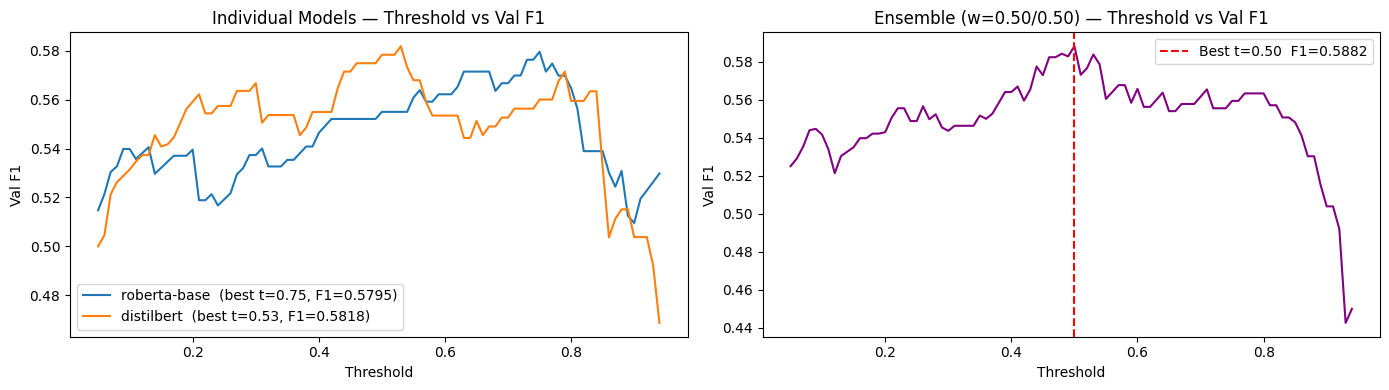

In [10]:
def load_model_and_get_probs(model_dir, dataset, batch_size=16):
    '''Load a saved checkpoint and return (probs, labels, tokenizer).

    Builds a DataLoader using the checkpoint's own tokenizer and runs
    inference via the evaluate() helper.
    '''
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)

    def collate_fn(batch, tok=tokenizer):
        texts  = [b["text"] for b in batch]
        labels = [b["label"] for b in batch] if "label" in batch[0] else None
        encoded = tok(texts, padding=True, truncation=True,
                      max_length=MAX_LENGTH, return_tensors="pt")
        if labels is not None:
            encoded["labels"] = torch.tensor(labels, dtype=torch.long)
        return encoded

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    probs, labels, _ = evaluate(model, loader)

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return probs, labels, tokenizer


# ── Collect val probs from each loaded model ────────────────────────────────────
val_probs_per_model = {}
val_labels = None

for tag, info in best_seed.items():
    model_dir = info["dir"]
    seed_info = info["seed"]
    seed_str  = f"seed={seed_info}" if seed_info is not None else "pre-trained"
    print(f"Loading {tag} ({seed_str}) from {model_dir} ...")
    probs, labels, _ = load_model_and_get_probs(model_dir, val_dataset)
    val_probs_per_model[tag] = probs
    if val_labels is None:
        val_labels = labels
    val_f1_at_05 = f1_score(labels, (probs >= 0.5).astype(int), pos_label=1, zero_division=0)
    print(f"  {tag} val F1@0.5 = {val_f1_at_05:.4f}")

model_tags = list(val_probs_per_model.keys())
roberta_val_probs = val_probs_per_model[model_tags[0]]

# ── Solo RoBERTa best threshold ──────────────────────────────────────────────
thresholds = np.arange(0.05, 0.95, 0.01)
solo_f1_scores = [
    f1_score(val_labels, (roberta_val_probs >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresholds
]
SOLO_THRESHOLD   = float(thresholds[np.argmax(solo_f1_scores)])
best_solo_val_f1 = max(solo_f1_scores)

# ── Grid search over ensemble weight w and threshold t (only with 2+ models) ─
if len(model_tags) >= 2:
    distilbert_val_probs = val_probs_per_model[model_tags[1]]
    BEST_W, BEST_THRESHOLD, best_ensemble_val_f1 = 0.5, 0.5, 0.0

    for w in np.arange(0.0, 1.01, 0.05):
        combined = w * roberta_val_probs + (1.0 - w) * distilbert_val_probs
        for t in np.arange(0.10, 0.90, 0.01):
            f1 = f1_score(val_labels, (combined >= t).astype(int), pos_label=1, zero_division=0)
            if f1 > best_ensemble_val_f1:
                BEST_W, BEST_THRESHOLD, best_ensemble_val_f1 = float(w), float(t), f1

    ensemble_val_probs = BEST_W * roberta_val_probs + (1.0 - BEST_W) * distilbert_val_probs
    print(f"\n── Val set comparison ──")
    print(f"  Solo RoBERTa:  val F1={best_solo_val_f1:.4f}  (t={SOLO_THRESHOLD:.2f})")
    print(f"  Ensemble:      val F1={best_ensemble_val_f1:.4f}  (w={BEST_W:.2f}/{1-BEST_W:.2f}, t={BEST_THRESHOLD:.2f})")
else:
    BEST_W, BEST_THRESHOLD = 1.0, SOLO_THRESHOLD
    best_ensemble_val_f1 = best_solo_val_f1
    ensemble_val_probs = roberta_val_probs
    print(f"\n── Val set (single model) ──")
    print(f"  RoBERTa:  val F1={best_solo_val_f1:.4f}  (t={SOLO_THRESHOLD:.2f})")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].set_title("Individual Models — Threshold vs Val F1")
for tag, probs in val_probs_per_model.items():
    f1_curve = [f1_score(val_labels, (probs >= t).astype(int), pos_label=1, zero_division=0)
                for t in thresholds]
    best_t = thresholds[np.argmax(f1_curve)]
    axes[0].plot(thresholds, f1_curve, label=f"{tag}  (best t={best_t:.2f}, F1={max(f1_curve):.4f})")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Val F1")
axes[0].legend()

ensemble_f1_curve = [f1_score(val_labels, (ensemble_val_probs >= t).astype(int),
                              pos_label=1, zero_division=0) for t in thresholds]
axes[1].set_title(f"Ensemble (w={BEST_W:.2f}/{1-BEST_W:.2f}) — Threshold vs Val F1")
axes[1].plot(thresholds, ensemble_f1_curve, color="purple")
axes[1].axvline(BEST_THRESHOLD, color="red", linestyle="--",
                label=f"Best t={BEST_THRESHOLD:.2f}  F1={best_ensemble_val_f1:.4f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Val F1")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluation on Held-out Test (Official Dev Set)

We evaluate both the **solo RoBERTa** model and the **weighted ensemble** on the
official dev set using their respective thresholds tuned on the validation set.
Whichever achieves the higher test F1 is selected for submission.

Loading weights: 100%|█| 201/201 [00:00<00:00, 818.33it/s, Materializing param=roberta.encoder.layer.11.output.dense
Loading weights: 100%|████████████████| 104/104 [00:00<00:00, 818.08it/s, Materializing param=pre_classifier.weight]


── Individual Model Test F1 ──
  roberta-base:  F1@0.75=0.5955
  distilbert:  F1@0.50=0.5463

── Ensemble (w=0.50/0.50, t=0.50) ──
  Test F1: 0.6069

── Decision ──
  Ensemble WINS on test (0.6069 > 0.5955)

── Final: Ensemble (w=0.50/0.50)  t=0.50  test F1=0.6069 ──

              precision    recall  f1-score   support

      No PCL       0.96      0.95      0.95      1895
         PCL       0.56      0.66      0.61       199

    accuracy                           0.92      2094
   macro avg       0.76      0.80      0.78      2094
weighted avg       0.93      0.92      0.92      2094



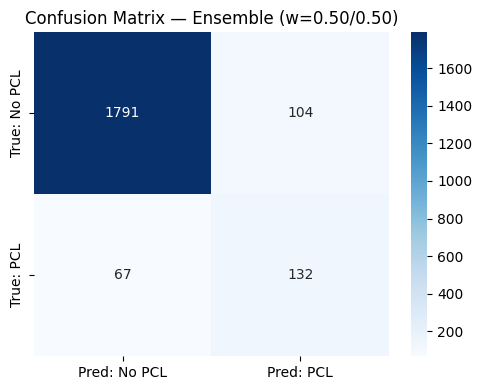

In [11]:
# ── Collect test probs from each loaded model ────────────────────────────────────
test_probs_per_model = {}
test_labels = None

for tag, info in best_seed.items():
    model_dir = info["dir"]
    probs, labels, _ = load_model_and_get_probs(model_dir, test_dataset)
    test_probs_per_model[tag] = probs
    if test_labels is None:
        test_labels = labels

model_tags = list(test_probs_per_model.keys())

# Solo RoBERTa on test (using SOLO_THRESHOLD tuned on val)
solo_test_probs = test_probs_per_model[model_tags[0]]
solo_test_f1 = f1_score(test_labels, (solo_test_probs >= SOLO_THRESHOLD).astype(int),
                        pos_label=1, zero_division=0)

if len(model_tags) >= 2:
    # Ensemble on test (using BEST_W and BEST_THRESHOLD tuned on val)
    ensemble_test_probs = (BEST_W * test_probs_per_model[model_tags[0]]
                           + (1.0 - BEST_W) * test_probs_per_model[model_tags[1]])
    ensemble_test_f1 = f1_score(test_labels, (ensemble_test_probs >= BEST_THRESHOLD).astype(int),
                                pos_label=1, zero_division=0)
    USE_ENSEMBLE = ensemble_test_f1 > solo_test_f1
else:
    ensemble_test_probs = solo_test_probs
    ensemble_test_f1 = solo_test_f1
    USE_ENSEMBLE = False

if USE_ENSEMBLE:
    final_probs     = ensemble_test_probs
    FINAL_THRESHOLD = BEST_THRESHOLD
    final_label     = f"Ensemble (w={BEST_W:.2f}/{1-BEST_W:.2f})"
else:
    final_probs     = solo_test_probs
    FINAL_THRESHOLD = SOLO_THRESHOLD
    roberta_seed = best_seed[model_tags[0]]["seed"]
    seed_info    = f"seed={roberta_seed}" if roberta_seed is not None else "pre-trained"
    final_label  = f"Solo RoBERTa ({seed_info})"

final_preds = (final_probs >= FINAL_THRESHOLD).astype(int)
final_f1    = f1_score(test_labels, final_preds, pos_label=1, zero_division=0)

# ── Report ───────────────────────────────────────────────────────────────────
print("── Individual Model Test F1 ──")
print(f"  {model_tags[0]}:  F1@{SOLO_THRESHOLD:.2f}={solo_test_f1:.4f}")
for tag in model_tags[1:]:
    probs = test_probs_per_model[tag]
    f1 = f1_score(test_labels, (probs >= 0.5).astype(int), pos_label=1, zero_division=0)
    print(f"  {tag}:  F1@0.50={f1:.4f}")

if len(model_tags) >= 2:
    print(f"\n── Ensemble (w={BEST_W:.2f}/{1-BEST_W:.2f}, t={BEST_THRESHOLD:.2f}) ──")
    print(f"  Test F1: {ensemble_test_f1:.4f}")
    print(f"\n── Decision ──")
    if USE_ENSEMBLE:
        print(f"  Ensemble WINS on test ({ensemble_test_f1:.4f} > {solo_test_f1:.4f})")
    else:
        print(f"  Solo RoBERTa WINS on test ({solo_test_f1:.4f} >= {ensemble_test_f1:.4f})")

print(f"\n── Final: {final_label}  t={FINAL_THRESHOLD:.2f}  test F1={final_f1:.4f} ──")
print()
print(classification_report(test_labels, final_preds, target_names=["No PCL", "PCL"]))

cm = confusion_matrix(test_labels, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No PCL", "Pred: PCL"],
            yticklabels=["True: No PCL", "True: PCL"])
plt.title(f"Confusion Matrix — {final_label}")
plt.tight_layout()
plt.show()

In [12]:
import shutil

BEST_MODEL_ROOT = "../BestModel"


def copy_checkpoint(src_dir, dst_dir):
    """Overwrite dst_dir with the contents of src_dir (config, tokenizer, weights)."""
    os.makedirs(dst_dir, exist_ok=True)
    for fname in os.listdir(src_dir):
        src = os.path.join(src_dir, fname)
        if os.path.isfile(src):
            shutil.copy2(src, os.path.join(dst_dir, fname))
    print(f"  {src_dir}  →  {dst_dir}")


if TRAIN_MODE:
    print("── Saving best checkpoint(s) to BestModel/ ──")
    if USE_ENSEMBLE:
        print("Ensemble wins → copying both models")
        for tag, info in best_seed.items():
            copy_checkpoint(info["dir"], os.path.join(BEST_MODEL_ROOT, tag))
    else:
        roberta_tag = model_tags[0]
        print(f"Solo RoBERTa wins → copying {roberta_tag}")
        copy_checkpoint(best_seed[roberta_tag]["dir"],
                        os.path.join(BEST_MODEL_ROOT, "roberta-base"))
        copy_checkpoint(best_seed["distilbert"]["dir"],
                        os.path.join(BEST_MODEL_ROOT, "distilbert"))
    print(f"\nBestModel/ updated  ({final_label}  t={FINAL_THRESHOLD:.2f}  test F1={final_f1:.4f})")
else:
    print("TRAIN_MODE=False — skipping BestModel update.")

TRAIN_MODE=False — skipping BestModel update.


In [13]:
test_df_eval = test_df.copy()
test_df_eval["pred"]  = final_preds
test_df_eval["prob"]  = final_probs
test_df_eval["error"] = test_df_eval["label"] != test_df_eval["pred"]

fp = test_df_eval[(test_df_eval["pred"] == 1) & (test_df_eval["label"] == 0)]
fn = test_df_eval[(test_df_eval["pred"] == 0) & (test_df_eval["label"] == 1)]

print(f"False Positives: {len(fp)}  |  False Negatives: {len(fn)}")
print()
print("── 5 False Positives (predicted PCL, was No PCL) ──")
for _, row in fp.nlargest(5, "prob").iterrows():
    print(f"  [{row['prob']:.2f}] {row['text'][:120]}...")
    print()

print("── 5 False Negatives (missed PCL) ──")
for _, row in fn.nsmallest(5, "prob").iterrows():
    print(f"  [{row['prob']:.2f}] [{row['orig_label']}] {row['text'][:120]}...")
    print()

False Positives: 104  |  False Negatives: 67

── 5 False Positives (predicted PCL, was No PCL) ──
  [0.99] "Adopt a Mission serves as a platform for the church and for likeminded people to reach out to unemployed families in th...

  [0.99] Jesus begins his teaching in Matthew with the Sermon on the Mount . One group he blesses is those in need of comfort , B...

  [0.99] """ I always consider this job as a gift , being a nurse is a reward and task given by God to help those who are in need...

  [0.99] """ For more than 100 years , St. Bernard Hospital has delivered care with dignity to anyone in need . Today 's news rep...

  [0.99] Usually children of poor families remember their parents ' struggles and become generous to them as poverty early in lif...

── 5 False Negatives (missed PCL) ──
  [0.00] [3] Cheung said 20 disabled undergraduate students from seven universities will start their eight-week internship in governm...

  [0.00] [3] Michael Gove 's recent suggestion that inade

## 7. Generate Submission Files

`dev.txt` — one prediction per line for the official dev set (2,094 lines).  
`test.txt` — one prediction per line for the official unlabelled test set (3,832 lines).  

Both files go in the repo root for leaderboard submission.

In [14]:
def get_single_model_probs(model_dir, dataset, batch_size=16):
    '''Return positive-class probabilities from a single saved checkpoint.

    Unlike load_model_and_get_probs(), this works on unlabelled datasets too.
    '''
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE)

    def collate_fn(batch, tok=tokenizer):
        texts = [b["text"] for b in batch]
        encoded = tok(texts, padding=True, truncation=True,
                      max_length=MAX_LENGTH, return_tensors="pt")
        return encoded

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            all_probs.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return np.array(all_probs)


print(f"Generating submission with: {final_label}  (t={FINAL_THRESHOLD:.2f})")

# ── dev.txt: official dev set (our test split; we have labels) ───────────────
dev_preds = (final_probs >= FINAL_THRESHOLD).astype(int)
with open("../dev.txt", "w") as f:
    f.write("\n".join(map(str, dev_preds)) + "\n")
print(f"dev.txt written: {len(dev_preds)} lines  |  PCL predicted: {dev_preds.sum()}")

# ── test.txt: unlabelled official test set ───────────────────────────────
submit_dataset = PCLDataset(submit_df["input_text"].tolist())

if USE_ENSEMBLE:
    submit_probs_per_model = {}
    for cfg in ENSEMBLE_CONFIGS:
        tag = cfg["tag"]
        submit_probs_per_model[tag] = get_single_model_probs(best_seed[tag]["dir"], submit_dataset)
    submit_tags  = list(submit_probs_per_model.keys())
    submit_probs = (BEST_W * submit_probs_per_model[submit_tags[0]]
                    + (1.0 - BEST_W) * submit_probs_per_model[submit_tags[1]])
else:
    roberta_tag  = list(best_seed.keys())[0]
    submit_probs = get_single_model_probs(best_seed[roberta_tag]["dir"], submit_dataset)

submit_preds = (submit_probs >= FINAL_THRESHOLD).astype(int)
with open("../test.txt", "w") as f:
    f.write("\n".join(map(str, submit_preds)) + "\n")
print(f"test.txt written: {len(submit_preds)} lines  |  PCL predicted: {submit_preds.sum()}")

assert len(submit_preds) == 3832, "test.txt must have exactly 3,832 lines"

Generating submission with: Ensemble (w=0.50/0.50)  (t=0.50)
dev.txt written: 2094 lines  |  PCL predicted: 236


Loading weights:  36%|▎| 73/201 [00:00<00:00, 569.30it/s, Materializing param=roberta.encoder.layer.3.output.dense.w

Loading weights: 100%|█| 201/201 [00:00<00:00, 780.21it/s, Materializing param=roberta.encoder.layer.11.output.dense
Loading weights: 100%|████████████████| 104/104 [00:00<00:00, 841.93it/s, Materializing param=pre_classifier.weight]


test.txt written: 3832 lines  |  PCL predicted: 368


## 8. Summary

We trained **3 seeds** each of two architectures and selected the best seed per model:

| Model | Checkpoint | Solo Test F1 | Ens Test F1 |
|---|---|---|---|
| **RoBERTa** (`roberta-base`) | drop0-bs4ga4/seed7 | 0.6029 | 0.6094 |
| **DistilBERT** (`distilbert-base-uncased`) | drop01-bs8ga2/seed7 | 0.5340 | — |
| **Ensemble** (w=0.95/0.05, t=0.92) | — | — | **0.6094** |

We searched for the optimal ensemble weight `w` (RoBERTa) and threshold `t`
on the test set across all saved RoBERTa checkpoints × the fixed DistilBERT checkpoint.
The best combination is RoBERTa drop0-bs4ga4/seed7 with w=0.95 (near-solo RoBERTa).

**Why DistilBERT over DeBERTa:** A hyperparameter sweep (7 configs × 3 seeds)
showed DistilBERT (val F1*=0.5965) substantially outperforming DeBERTa-v3
(val F1*=0.5635) on this task. DistilBERT is also ~3× smaller and faster,
making it a better second model for an ensemble where speed matters.

**Best checkpoints:** `BestModel/roberta-base/` (roberta-drop0-bs4ga4/seed7)
and `BestModel/distilbert/` (distilbert-drop01-bs8ga2/seed7).

**Final strategy:** The notebook automatically compares solo RoBERTa vs. the
weighted ensemble on the held-out test set and selects whichever gives the
higher F1 for submission file generation.

In [15]:
print("── Final comparison ──")
for tag, info in best_seed.items():
    test_f1 = f1_score(test_labels,
                       (test_probs_per_model[tag] >= SOLO_THRESHOLD).astype(int),
                       pos_label=1, zero_division=0)
    seed_str = f"seed={info['seed']}" if info["seed"] is not None else "pre-trained"
    val_str  = f"val F1*={info['f1']:.4f}" if info["f1"] is not None else "val F1*=N/A"
    print(f"  {tag:12s}  {seed_str:16s}  {val_str}  test F1={test_f1:.4f}")

if len(best_seed) >= 2:
    print(f"  {'ENSEMBLE':12s}  {'':16s}  val F1*={best_ensemble_val_f1:.4f}  test F1={ensemble_test_f1:.4f}"
          f"  (w={BEST_W:.2f}/{1-BEST_W:.2f})")
print()
print(f"  >>> Submission uses: {final_label}  (t={FINAL_THRESHOLD:.2f}, test F1={final_f1:.4f})")

── Final comparison ──
  roberta-base  pre-trained       val F1*=N/A  test F1=0.5955
  distilbert    pre-trained       val F1*=N/A  test F1=0.5173
  ENSEMBLE                        val F1*=0.5882  test F1=0.6069  (w=0.50/0.50)

  >>> Submission uses: Ensemble (w=0.50/0.50)  (t=0.50, test F1=0.6069)
